In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from getdist import MCSamples, plots

In [2]:
plt.rcParams.update({"text.usetex":True})

In [3]:
def load_samples(cosmo, telescope, sim='lcdm', calib=False, overwrite_name=None):
    """
    e.g. test_lcdm_chain_sig8_m25_DESI.npy
    """
    chain_file = "chains/test_"+sim+"_chain"
    chain_sig8_file = "test_"+sim+"_chain_sig8"
    if cosmo == "cdm":
        names = ['logAs', 'Om', 'sig8']
        labels = ['\ln 10^{10} A_s', '\Omega_m', '\sigma_8']
        if telescope == "boss":
            chain_name = "BOSS + eBOSS"
        elif telescope == "euclid":
            chain_file += "_Euclid"
            chain_sig8_file += "_Euclid"
            chain_name = "Euclid"
        elif telescope == "desi":
            chain_file += "_DESI"
            chain_sig8_file += "_DESI"
            chain_name = "DESI"
    
    elif cosmo == "axions":
        names = ['logAs', 'Om',  'fax', 'sig8']
        labels = ['\ln 10^{10} A_s', '\Omega_m', 'f_\mathrm{ax}', '\sigma_8']
        if telescope == "boss":
            chain_name = "BOSS + eBOSS"
            chain_file += "_m25"
            chain_sig8_file += "_m25"
        elif telescope == "euclid":
            chain_file += "_m25_Euclid"
            chain_sig8_file += "_m25_Euclid"
            chain_name = "Euclid"
        elif telescope == "desi":
            chain_file += "_m25_DESI"
            chain_sig8_file += "_m25_DESI"
            chain_name = "DESI"

    if calib:
        chain_file += "_calib"
        chain_sig8_file += "_calib"
    
    if overwrite_name is None:
        chain_name = "$\mathrm{" + chain_name + "}$"
    else:
        chain_name = overwrite_name
    
    s = np.load(chain_file + ".npy")
    samps = np.zeros((s.shape[0], s.shape[1]+1))
    
    samps[:, :s.shape[1]] = s

    s_sig8 = np.load("chains/"+chain_sig8_file + ".npy")
    samps[:, s.shape[1]] = np.array([s_sig8[i][0] for i in range(len(s))])

    samples = MCSamples(samples=samps, names=names, labels=labels, 
                    settings={'ignore_rows':0.3}, ranges={'fax':(0, 0.5)}, label=chain_name)

    return samples

<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\O'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\O'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\O'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\O'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:42: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_90823/3820955047.py:9: SyntaxWarning: invalid escape sequence '\l'
  labels = ['\ln 10^{10} A_s', '\Omega_m', '\sigma_8']
/tmp/ipykernel_90823/3820955047.py:9: SyntaxWarning: 

In [4]:
def make_triangle_plot(sample_list, axions=False, savename=None, markers={'logAs':3.043, 'Om':0.31, 'sig8':0.80}):

    g = plots.get_subplot_plotter()
    g.settings.axes_fontsize=18
    g.settings.axes_labelsize=22
    g.settings.legend_fontsize=16

    if axions:
        g.settings.axes_fontsize=22
        g.settings.axes_labelsize=26
        g.settings.legend_fontsize=22
    
    g.settings.linewidth=2
    #g.settings.solid_colors='Dark2_r'

    params = ['logAs', 'Om', 'sig8',]
    if axions:
        params.append('fax')

    g.triangle_plot(sample_list,
                params=params, filled=True,   markers=markers,) #colors=cm.Dark2_r, )

    if savename is not None:
        plt.savefig('figures/' + savename)

    plt.show()
    return

## LCDM Simulation forecast

In [5]:
CDM_sim_CDM_model_BOSS = load_samples("cdm", "boss")
CDM_sim_CDM_model_Euclid = load_samples("cdm", "euclid")
CDM_sim_CDM_model_DESI = load_samples("cdm", "desi")

Removed 0.3 as burn in
Removed 0.3 as burn in
Removed 0.3 as burn in


In [6]:
CDM_sim_Axions_model_BOSS = load_samples("axions", "boss")
CDM_sim_Axions_model_Euclid = load_samples("axions", "euclid")
CDM_sim_Axions_model_DESI = load_samples("axions", "desi")

Removed 0.3 as burn in
Removed 0.3 as burn in
Removed 0.3 as burn in


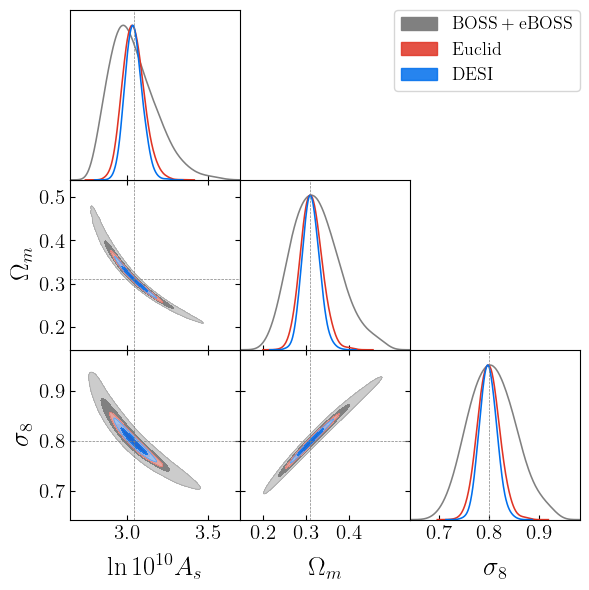

In [7]:

#g.triangle_plot([CDM_BOSS, CDM_Euclid, CDM_DESI],
#                params=['logAs', 'Om', 'sig8',], filled=True,   markers={'logAs':3.043, 'Om':0.31})

#plt.suptitle("$\mathrm{Validation:\;CDM\;Model\;with\;CDM\;Simulation\;(no\;priors)}$")
#plt.savefig('figures/VSF_samples_LCDM_only.png')

make_triangle_plot([CDM_sim_CDM_model_BOSS, CDM_sim_CDM_model_Euclid, CDM_sim_CDM_model_DESI], )#savename="VSF_samples_LCDM_only.png")

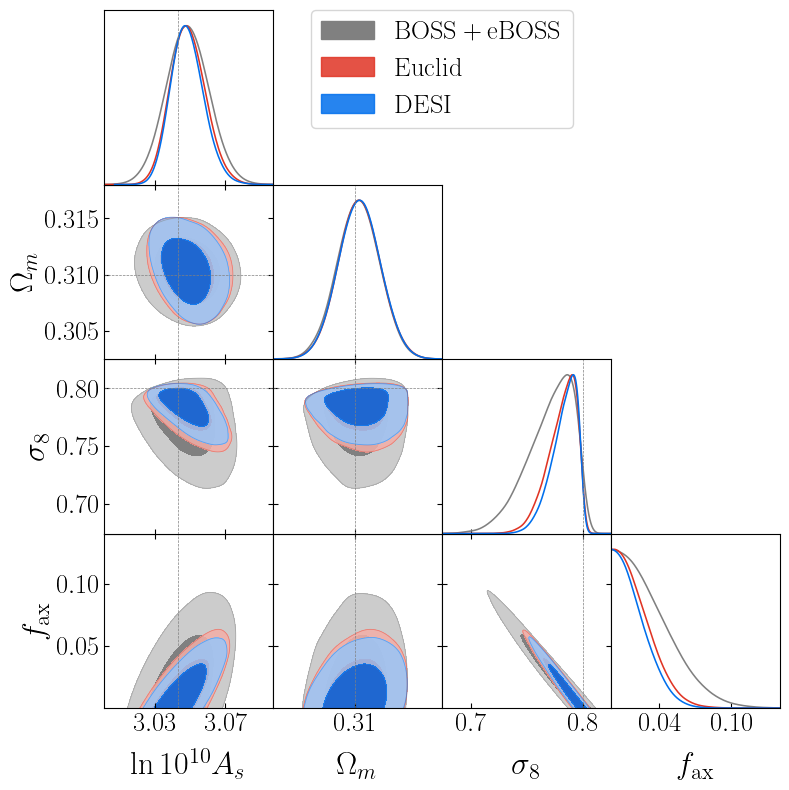

In [8]:
#plt.savefig('figures/VSF_samples_LCDM_with_m25.png')
make_triangle_plot([CDM_sim_Axions_model_BOSS, CDM_sim_Axions_model_Euclid, CDM_sim_Axions_model_DESI], axions=True, 
                #savename="VSF_samples_LCDM_with_m25.png"
                  )

In [9]:
#g = plots.get_subplot_plotter()
#g.triangle_plot([Axions_BOSS, Axions_Euclid, Axions_DESI],
#                params=['logAs', 'Om', 'sig8', 'fax'], filled=True,   markers={'logAs':3.043, 'Om':0.31})
#plt.savefig('figures/VSF_samples_LCDM_with_m25.png')

In [9]:
print(CDM_sim_Axions_model_BOSS.getInlineLatex('fax',limit=2))
print(CDM_sim_Axions_model_Euclid.getInlineLatex('fax',limit=2))
print(CDM_sim_Axions_model_DESI.getInlineLatex('fax',limit=2))
#print(Axions_Euclid.getTable(limit=2).tableTex())
#print(Axions_DESI.getTable(limit=2).tableTex())


f_\mathrm{ax} < 0.0747
f_\mathrm{ax} < 0.0505
f_\mathrm{ax} < 0.0456


## m25 Simulation forecast

In [7]:
Axions_sim_CDM_model_BOSS = load_samples("cdm", "boss", sim="m25")
Axions_sim_CDM_model_Euclid = load_samples("cdm", "euclid", sim="m25")
Axions_sim_CDM_model_DESI = load_samples("cdm", "desi", sim="m25")

Removed 0.3 as burn in
Removed 0.3 as burn in
Removed 0.3 as burn in


In [8]:
Axions_sim_Axions_model_BOSS = load_samples("axions", "boss", sim="m25")
Axions_sim_Axions_model_Euclid = load_samples("axions", "euclid", sim="m25")
Axions_sim_Axions_model_DESI = load_samples("axions", "desi", sim="m25")

Removed 0.3 as burn in
Removed 0.3 as burn in
Removed 0.3 as burn in


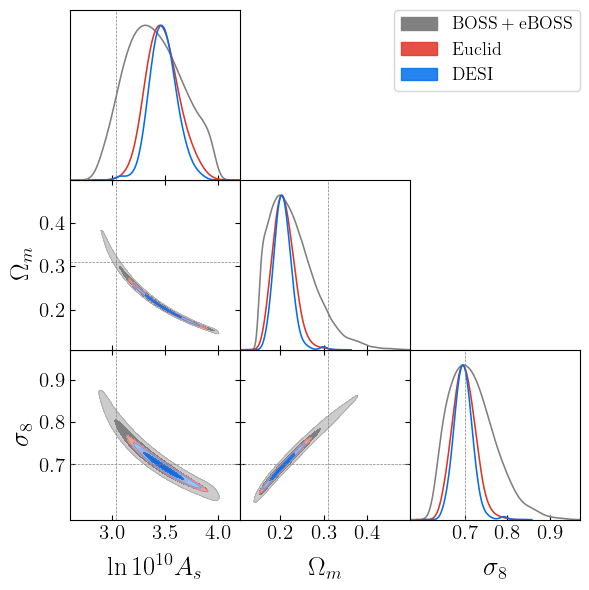

In [12]:
make_triangle_plot([Axions_sim_CDM_model_BOSS, Axions_sim_CDM_model_Euclid, Axions_sim_CDM_model_DESI], 
                   markers={'logAs':3.043, 'Om':0.31, 'sig8':0.7},
                   #savename="VSF_samples_m25_with_LCDM.png"
                  )

In [13]:
print(Axions_sim_CDM_model_BOSS.getTable(limit=1).tableTex())

\begin{tabular} { l  c}

 Parameter &  68\% limits\\
\hline
{\boldmath$\ln 10^{10} A_s$} & $3.41^{+0.24}_{-0.32}      $\\

{\boldmath$\Omega_m       $} & $0.229^{+0.026}_{-0.069}   $\\

{\boldmath$\sigma_8       $} & $0.717^{+0.038}_{-0.068}   $\\
\hline
\end{tabular}


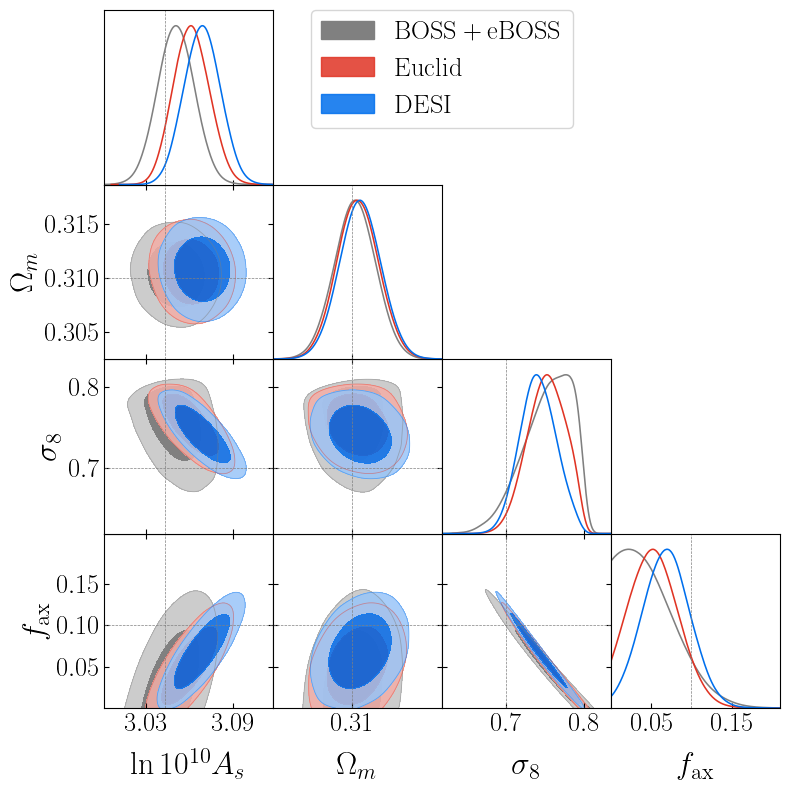

In [14]:
make_triangle_plot([Axions_sim_Axions_model_BOSS, Axions_sim_Axions_model_Euclid, Axions_sim_Axions_model_DESI], 
                   axions=True, markers={'logAs':3.043, 'Om':0.31, 'fax':0.1, 'sig8':0.7}, 
                   #savename="VSF_samples_m25_with_m25.png"
                  )

In [60]:
for c in [Axions_sim_Axions_model_BOSS, Axions_sim_Axions_model_Euclid, Axions_sim_Axions_model_DESI]:
    print(c.getInlineLatex('fax',limit=1))
    print(c.getInlineLatex('fax',limit=2))
    print("="*50)

f_\mathrm{ax} < 0.0620
f_\mathrm{ax} < 0.114
f_\mathrm{ax} = 0.055^{+0.026}_{-0.034}
f_\mathrm{ax} < 0.106
f_\mathrm{ax} = 0.069\pm 0.029
f_\mathrm{ax} = 0.069^{+0.055}_{-0.057}


In [10]:
#g = plots.get_subplot_plotter()
#g.triangle_plot([CDM_BOSS, CDM_Euclid, CDM_DESI],
#                params=['logAs', 'Om', 'sig8', ], filled=True,   markers={'logAs':3.043, 'Om':0.31, 'fax':0.1})

In [85]:
#new_Axions_sim_Axions_model_BOSS = Axions_sim_Axions_model_BOSS.copy() # make a copy so don't change the original
#new_loglike = (Axions_sim_Axions_model_BOSS['Om']-0.31)**2/0.005**2/2
#new_Axions_sim_Axions_model_BOSS.reweightAddingLogLikes(new_loglike)


#new_Axions_sim_Axions_model_Euclid = Axions_sim_Axions_model_Euclid.copy() # make a copy so don't change the original
#new_loglike = (Axions_sim_Axions_model_Euclid['Om']-0.31)**2/0.005**2/2
#new_Axions_sim_Axions_model_Euclid.reweightAddingLogLikes(new_loglike)

#new_Axions_sim_Axions_model_DESI = Axions_sim_Axions_model_DESI.copy() # make a copy so don't change the original
##new_loglike = (Axions_sim_Axions_model_DESI['Om']-0.31)**2/0.005**2/2
#new_Axions_sim_Axions_model_DESI.reweightAddingLogLikes(new_loglike)

In [86]:
#make_triangle_plot([new_Axions_sim_Axions_model_BOSS, new_Axions_sim_Axions_model_Euclid, new_Axions_sim_Axions_model_DESI], 
#                   axions=True,markers={'logAs':3.043, 'Om':0.31, 'fax':0.1})

In [96]:
print(CDM_sim_CDM_model_DESI.getTable(limit=1).tableTex())

\begin{tabular} { l  c}

 Parameter &  68\% limits\\
\hline
{\boldmath$\ln 10^{10} A_s$} & $3.042^{+0.048}_{-0.058}   $\\

{\boldmath$\Omega_m       $} & $0.312^{+0.019}_{-0.021}   $\\

{\boldmath$\sigma_8       $} & $0.799\pm 0.018            $\\
\hline
\end{tabular}


In [91]:
# corrected calibration

Axions_sim_Axions_model_BOSS_calib = load_samples("axions", "boss", sim="m25", calib=True)
Axions_sim_Axions_model_Euclid_calib = load_samples("axions", "euclid", sim="m25", calib=True)
Axions_sim_Axions_model_DESI_calib = load_samples("axions", "desi", sim="m25", calib=True)

Removed 0.3 as burn in
Removed 0.3 as burn in
Removed 0.3 as burn in


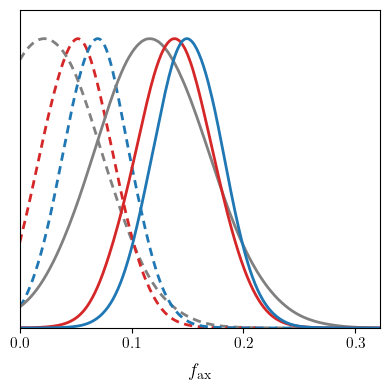

In [92]:
#g = plots.get_single_plotter(width_inch=3)
g = plots.get_subplot_plotter(subplot_size=4)
g.plot_1d([Axions_sim_Axions_model_BOSS, Axions_sim_Axions_model_Euclid, Axions_sim_Axions_model_DESI,
           Axions_sim_Axions_model_BOSS_calib, Axions_sim_Axions_model_Euclid_calib, Axions_sim_Axions_model_DESI_calib],
          'fax', 
          line_args=[{'lw':2, 'ls':'--', 'color':'grey'},
                     {'lw':2, 'ls':'--', 'color':'C3'},
                     {'lw':2, 'ls':'--', 'color':'C0'},
                     {'lw':2, 'ls':'-', 'color':'grey'}, 
                     {'lw':2, 'ls':'-', 'color':'C3'},
                     {'lw':2, 'ls':'-', 'color':'C0'}], legend_ncol=3, nx=1)


In [21]:
make_triangle_plot([Axions_sim_Axions_model_BOSS_calib, Axions_sim_Axions_model_Euclid_calib, Axions_sim_Axions_model_DESI_calib], 
                   axions=True, markers={'logAs':3.043, 'Om':0.31, 'fax':0.1, 'sig8':0.7},)

NameError: name 'Axions_sim_Axions_model_BOSS_calib' is not defined

In [94]:
print(Axions_sim_Axions_model_DESI_calib.getTable(limit=1).tableTex())

\begin{tabular} { l  c}

 Parameter &  68\% limits\\
\hline
{\boldmath$\ln 10^{10} A_s$} & $3.061\pm 0.013            $\\

{\boldmath$\Omega_m       $} & $0.3106\pm 0.0020          $\\

{\boldmath$f_\mathrm{ax}  $} & $0.150\pm 0.031            $\\

{\boldmath$\sigma_8       $} & $0.667^{+0.019}_{-0.022}   $\\
\hline
\end{tabular}


In [75]:
Axions_sim_Axions_model_Euclid_calib.getInlineLatex('fax',limit=2)

'f_\\mathrm{ax} = 0.138^{+0.068}_{-0.067}'

## Comparison with other probes

In [9]:
ctest = np.loadtxt('/home/alex/Documents/axions/axionVoids/chains/Keir_chains/'
                   +'SPT3G_Planck18TPlens_ACT_BAO_JLA_m25_fix_nuisance_prior_basenu_mn.txt')

In [16]:
np.average(ctest, axis=0, weights=ctest[:,-1])

array([ 1.00072806e+00,  5.29001166e-02,  6.75749026e-01,  2.24284627e-02,
        9.68667336e-01,  2.12374783e-09,  5.80970643e-02,  6.63001249e-02,
        1.00370169e+00, -7.06106792e-02,  1.41446252e-01,  3.10121906e+00,
       -1.91179158e+01,  7.54167980e-01,  3.54312197e+01, -1.54683469e+03,
       -1.51140347e+03,  2.19935872e-04])

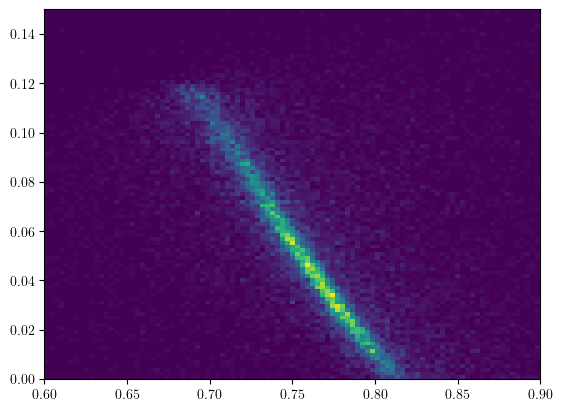

In [17]:
plt.hist2d(ctest[:,13], ctest[:,1], bins=[np.linspace(.6, 0.9, 100), np.linspace(0, 0.15, 100)]);

In [24]:
'''
0 actpol--yp     
1 axion_parameters--omaxh2        
2 cosmological_parameters--h0     
3 cosmological_parameters--ombh2  
4 cosmological_parameters--n_s    
5 cosmological_parameters--a_s    
6 cosmological_parameters--tau    
7 cosmological_parameters--omch2  
8 planck--a_planck        
9 supernova_params--deltam        
10 supernova_params--alpha supernova_params--beta  
11 supernova_params--m     
12 COSMOLOGICAL_PARAMETERS--SIGMA_8        
13 prior   
14 like    
15 post    
16 weight
'''


'actpol--yp     axion_parameters--omaxh2        cosmological_parameters--h0     cosmological_parameters--ombh2  cosmological_parameters--n_s    cosmological_parameters--a_s    cosmological_parameters--tau    cosmological_parameters--omch2  planck--a_planck        supernova_params--deltam        supernova_params--alpha supernova_params--beta  supernova_params--m     COSMOLOGICAL_PARAMETERS--SIGMA_8        prior   like    post    weight'

In [10]:
Keir_samples_sig8 = ctest[:,13]
Keir_samples_omaxh2 = ctest[:,1]
Keir_samples_ombh2 = ctest[:,3]
Keir_samples_omch2 = ctest[:,7]
Keir_samples_h = ctest[:,2]
Keir_samples_fax = Keir_samples_omaxh2 / (Keir_samples_omaxh2+Keir_samples_omch2)
Keir_samples_Om = (Keir_samples_omaxh2 + Keir_samples_omch2 + Keir_samples_ombh2) / Keir_samples_h**2
Keir_samples_ln10As = np.log(1e10*ctest[:,5])
Keir_samples_S8 = Keir_samples_sig8*(Keir_samples_Om/0.3)**.5
csamples =  MCSamples(samples=[Keir_samples_sig8, Keir_samples_fax, Keir_samples_Om, 
                               Keir_samples_ln10As, Keir_samples_omaxh2, Keir_samples_S8], 
                      names=['sig8', 'fax', 'Om', 'logAs','omaxh2', 'S8'], 
                      labels=['\sigma_8', 'f_\mathrm{ax}', '\Omega_m', '\ln 10^{10} A_s','omaxh2', 'S_8\equiv \sigma_8\sqrt{\Omega_m/0.3}'], 
                    settings={'ignore_rows':0.0}, ranges={'fax':(0, 0.15), 'omaxh2':(0, None)}, weights=ctest[:,-1], 
                      label="$\mathrm{CMB\;(SPT/Planck/ACT)+ SNe + BAO}$")

Removed no burn in


<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\O'
<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\O'
<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_90823/1790899914.py:13: SyntaxWarning: invalid escape sequence '\s'
  labels=['\sigma_8', 'f_\mathrm{ax}', '\Omega_m', '\ln 10^{10} A_s','omaxh2', 'S_8\equiv \sigma_8\sqrt{\Omega_m/0.3}'],
/tmp/ipykernel_90823/1790899914.py:13: SyntaxWarning: invalid escape sequence '\m'
  labels=['\sigma_8', 'f_\mathrm{ax}', '\Omega_m', '\ln 10^{10} A_s','omaxh2', 'S_8\equiv \sigma_8\sq

In [15]:
CDM_sim_Axions_model_BOSS = load_samples("axions", "boss", 
                                         overwrite_name="$\mathrm{CMB\;Prior\;}(\Omega_m,A_s)\mathrm{+VSF\;(BOSS/eBOSS)}$")
CDM_sim_Axions_model_Euclid = load_samples("axions", "euclid", 
                                           overwrite_name="$\mathrm{CMB\;Prior\;}(\Omega_m,A_s)\mathrm{+VSF\;(Euclid)}$")
CDM_sim_Axions_model_DESI = load_samples("axions", "desi", 
                                         overwrite_name="$\mathrm{CMB\;Prior\;}(\Omega_m,A_s)\mathrm{+VSF\;(DESI)}$")

p = CDM_sim_Axions_model_BOSS.getParams() 
#CDM_sim_Axions_model_BOSS.addDerived(p.fax*(p.Om*0.68**2-0.022), name='omaxh2', label='\Omega_\mathrm{ax}h^2', )
p = CDM_sim_Axions_model_BOSS.getParams() 
CDM_sim_Axions_model_BOSS.addDerived(p.sig8*(p.Om/0.3)**0.5, name='S8', label='S_8\equiv \sigma_8\sqrt{\Omega_m/0.3}', )
p = CDM_sim_Axions_model_Euclid.getParams() 
CDM_sim_Axions_model_Euclid.addDerived(p.sig8*(p.Om/0.3)**0.5, name='S8', label='S_8\equiv \sigma_8\sqrt{\Omega_m/0.3}', )
p = CDM_sim_Axions_model_DESI.getParams() 
CDM_sim_Axions_model_DESI.addDerived(p.sig8*(p.Om/0.3)**0.5, name='S8', label='S_8\equiv \sigma_8\sqrt{\Omega_m/0.3}', )

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:13: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:13: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_90823/1406089075.py:2: SyntaxWarning: invalid escape sequence '\m'
  overwrite_name="$\mathrm{CMB\;Prior\;}(\Omega_m,A_s)\mathrm{+VSF\;(BOSS/eBOSS)}$")
/tmp/ipykernel_90823/1406089075.py:4: SyntaxWarning: invalid escape sequence '\m'
  overwrite_name="$\mathrm{CMB\;Prior\;}(\Omega_m,A_s)\mathrm{+VSF\;(Euclid)}$")
/tmp/ipykernel_90823/1406089075.py:6: SyntaxWarning: invalid esc

Removed 0.3 as burn in
Removed 0.3 as burn in
Removed 0.3 as burn in


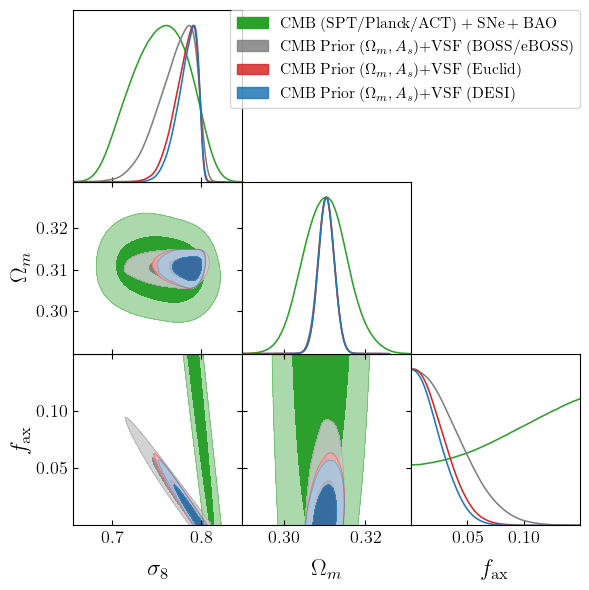

In [16]:
g = plots.get_subplot_plotter()
g.settings.axes_fontsize=16
g.settings.axes_labelsize=20
g.settings.legend_fontsize=14.2

g.settings.linewidth=2
g.triangle_plot([csamples, CDM_sim_Axions_model_BOSS, CDM_sim_Axions_model_Euclid, CDM_sim_Axions_model_DESI], 
                ['sig8', 'Om', 'fax'], filled=[True, True, True, True], contour_colors=['C2', 'grey', 'C3', 'C0'])
#plt.savefig('figures/combination-with-CMB.png', dpi=600)

In [61]:
np.mean(chain_32pt[:,0])

0.32171186757949205

In [88]:
chain_DES = np.loadtxt('chains/Keir_chains/chain_3x2pt_fixednu_lcdm.txt')

DES_samples =  MCSamples(samples=[chain_DES[:,-7], chain_DES[:,0], np.log(1e10*chain_DES[:,4]), 
                                 chain_DES[:,-7]*np.sqrt(chain_DES[:,0]/0.3)], 
                      names=['sig8', 'Om', 'logAs', 'S8'], 
                      labels=['\sigma_8',  '\Omega_m', '\ln 10^{10} A_s', 'S_8\equiv \sigma_8\sqrt{\Omega_m/0.3}'], 
                    settings={'ignore_rows':0.0}, weights=chain_DES[:,-1], 
                      label="$\mathrm{WL\;(DES\;Y3)}$")

chain_kids = np.loadtxt('chains/Keir_chains/samples_multinest_blindC_EE_nE_w.txt')

kids_samples =  MCSamples(samples=[chain_kids[:,-21], chain_kids[:,-18], np.log(1e10*chain_kids[:,-19]), 
                                 chain_kids[:,-21]*np.sqrt(chain_kids[:,-18]/0.3)], 
                      names=['sig8', 'Om', 'logAs', 'S8'], 
                      labels=['\sigma_8',  '\Omega_m', '\ln 10^{10} A_s', 'S_8\equiv \sigma_8\sqrt{\Omega_m/0.3}'], 
                    settings={'ignore_rows':0.0}, weights=chain_kids[:,-1], 
                      label="$\mathrm{WL\;(KiDS)}$")

Removed no burn in
Removed no burn in


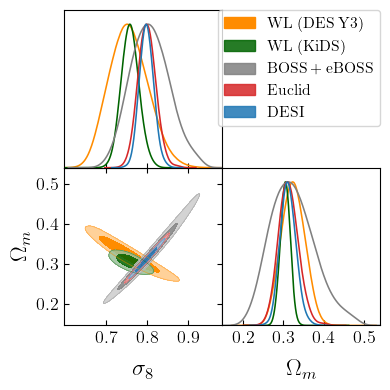

In [92]:
g = plots.get_subplot_plotter()
g.settings.axes_fontsize=16
g.settings.axes_labelsize=20
g.settings.legend_fontsize=14.2

g.settings.linewidth=2
g.triangle_plot([DES_samples, kids_samples, CDM_sim_CDM_model_BOSS, CDM_sim_CDM_model_Euclid, CDM_sim_CDM_model_DESI], 
                ['sig8', 'Om'], filled=[True, True, True, True], contour_colors=['darkorange','darkgreen', 'grey', 'C3', 'C0'])
plt.savefig('figures/combination-with-WL.png', dpi=600)

## Calibrating $b_{eff}$

In [2]:
h = 0.68
R_array = np.geomspace(5, 85, 1_000)
Nbins = 10
bin_edges = np.geomspace(25, 40, Nbins+1)
bin_cens = (bin_edges[:-1]+bin_edges[1:])/2
lcdm_void_radii = np.loadtxt('data/test_new_radii_lcdm.dat')
N_data = np.histogram(lcdm_void_radii, bins=bin_edges)[0]
boxsize = 2048*h

In [3]:
from model import VSF_model, get_pk_interp, variance

/home/alex/Documents/axions/axionHMcode_fast/solvers/root_finders.py:8: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def brent(f, x1, x3):
/home/alex/Documents/axions/axionHMcode_fast/solvers/root_finders.py:34: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def newton(f, x0, y=0, args=None):


Time to generate Pk from interpolation:  0.0014620839999999191


Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG IEEE_DENORMAL


In [4]:
k, Pk = get_pk_interp([3.043, 0.31, 0.001])

In [6]:
R_array = np.geomspace(5, 85, 1000)

In [7]:
from scipy.integrate import cumtrapz


s = [(R_array > bin_edges[i]) & (R_array < bin_edges[i+1]) for i in range(Nbins)]
R, var = variance(k, Pk)
mod = VSF_model(1.26, R, var)
model = mod[0]


#N_model = [np.trapz(model[s[j]], x=np.log(R_array[s[j]])) for j in range(Nbins)]
#N_model = boxsize**3 * np.array(N_model)
#N_model = cumtrapz(model, x=np.log(R_array))
#N_model = np.array([N_model[np.argmin(abs(R_array-bin_edges[j+1]))] - N_model[np.argmin(abs(R_array-bin_edges[j]))]  for j in range(Nbins)])
#N_model *= boxsize**3
N_model = [np.trapz(model[s[j]], x=np.log(R_array[s[j]])) for j in range(Nbins)]
N_model = boxsize**3 * np.array(N_model)

In [6]:
mod[0].shape

(1000,)

In [8]:
N_model

array([130.68101108,  84.50402786,  60.35972701,  36.55771239,
        24.27419823,  13.53510656,   8.19262911,   4.30567794,
         2.0238047 ,   1.01230657])

In [9]:
N_data

array([168, 137,  91,  82,  41,  36,  15,   9,   5,   2])

In [86]:
from scipy.special import factorial

In [228]:
s = [(R_array > bin_edges[i]) & (R_array < bin_edges[i+1]) for i in range(Nbins)]
def to_min(b):
    p = [3.043, 0.31]
    params = [p[0], p[1], 0.001]
    k, P = get_pk_interp(params)

    # select R range for bin
    s = [(R_array > bin_edges[i]) & (R_array < bin_edges[i+1]) for i in range(Nbins)]
    model, sig8 = VSF_model(b, k, P)

    # integrate model over R-range                  
    N_model = [np.trapz(model[s[j]], x=np.log(R_array[s[j]])) for j in range(Nbins)]
    N_model = boxsize**3 * np.array(N_model)

    # Compare with data assuming Poisson likelihood
    #likelihood = np.prod(N_model[1:-2]**N_data[1:-2] * np.exp(-N_model[1:-2]) / factorial(N_data[1:-2]))
    log_like = np.sum((N_data*np.log(N_model) - N_model - np.log(factorial(N_data)))[1:-1])
    
    #if likelihood <= 0:
        #print("Non-finite error")
    #    return np.inf#-1000 

    #print(np.log(likelihood)) 
    return -log_like #-np.log(likelihood)


In [229]:
minimize(to_min, x0=[1.34], method='Nelder-Mead')

 final_simplex: (array([[1.36355469],
       [1.36362012]]), array([25.6002412 , 25.60026304]))
           fun: 25.600241204001083
       message: 'Optimization terminated successfully.'
          nfev: 22
           nit: 11
        status: 0
       success: True
             x: array([1.36355469])

In [230]:
def to_min(p):
    params = [p[0], p[1], 0.001]
    k, P = get_pk_interp(params)

    # select R range for bin
    s = [(R_array > bin_edges[i]) & (R_array < bin_edges[i+1]) for i in range(Nbins)]
    model, sig8 = VSF_model(1.36355, k, P)

    # integrate model over R-range                  
    N_model = [np.trapz(model[s[j]], x=np.log(R_array[s[j]])) for j in range(Nbins)]
    N_model = boxsize**3 * np.array(N_model)

    # Compare with data assuming Poisson likelihood
    #likelihood = np.prod(N_model[1:-1]**N_data[1:-1] * np.exp(-N_model[1:-1]) / factorial(N_data[1:-1]))
    log_like = np.sum((N_data*np.log(N_model) - N_model - np.log(factorial(N_data)))[1:-1])
    
    #if likelihood <= 0:
        #print("Non-finite error")
    #    return np.inf#-1000 

    #print(np.log(likelihood)) 
    return -log_like #-np.log(likelihood)


In [231]:
minimize(to_min, x0=[3.043, 0.31], method='Nelder-Mead')

 final_simplex: (array([[3.04296117, 0.31003538],
       [3.0428905 , 0.31009254],
       [3.04295417, 0.310049  ]]), array([25.60024007, 25.6002401 , 25.60024032]))
           fun: 25.60024006923603
       message: 'Optimization terminated successfully.'
          nfev: 49
           nit: 25
        status: 0
       success: True
             x: array([3.04296117, 0.31003538])

In [13]:
from scipy.optimize import minimize

In [233]:
to_min([3.043, 0.21])

324.8028467766888

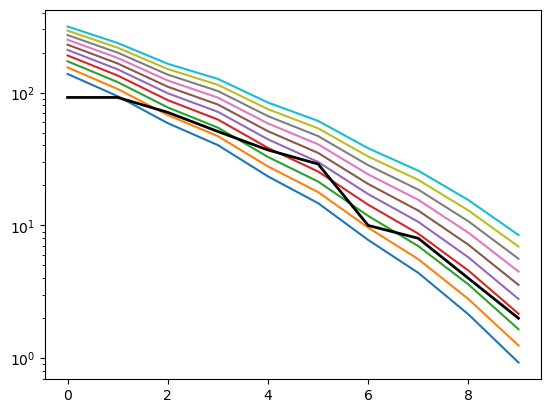

In [48]:


s = [(R_array > bin_edges[i]) & (R_array < bin_edges[i+1]) for i in range(Nbins)]

for lnA in np.linspace(3, 3.2, 10):
    k, Pk = get_pk_interp([lnA, 0.31, 0.001])
    mod = VSF_model(1.315, k, Pk)
    model = mod[0]
    
    N_model = cumtrapz(model, x=np.log(R_array))
    N_model = np.array([N_model[np.argmin(abs(R_array-bin_edges[j+1]))] 
                        - N_model[np.argmin(abs(R_array-bin_edges[j]))]  for j in range(Nbins)])
    N_model *= boxsize**3
    plt.plot(N_model)

plt.plot(N_data, c='k', lw=2)
plt.yscale('log')

(1.0, 300.0)

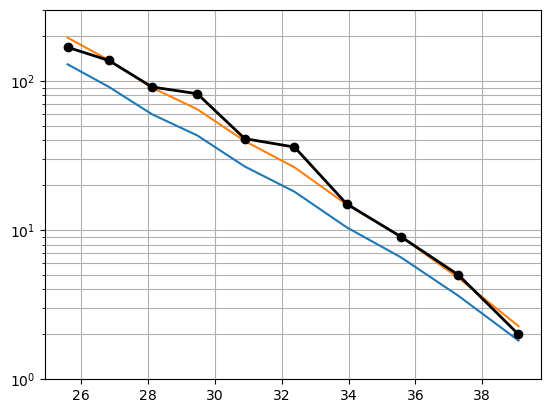

In [219]:
s = [(R_array > bin_edges[i]) & (R_array < bin_edges[i+1]) for i in range(Nbins)]

#for Om in [0.158]:#np.linspace(.15, .4, 10):
k, Pk = get_pk_interp([3.21, .223, 0.001])
mod = VSF_model(1.28, k, Pk)
model = mod[0]
    
N_model = cumtrapz(model, x=np.log(R_array))
N_model = np.array([N_model[np.argmin(abs(R_array-bin_edges[j+1]))] 
                        - N_model[np.argmin(abs(R_array-bin_edges[j]))]  for j in range(Nbins)])
N_model *= boxsize**3
plt.plot(bin_cens, N_model)

k, Pk = get_pk_interp([3.043, .31, 0.001])
mod = VSF_model(1.34, k, Pk)
model = mod[0]
    
N_model = cumtrapz(model, x=np.log(R_array))
N_model = np.array([N_model[np.argmin(abs(R_array-bin_edges[j+1]))] 
                        - N_model[np.argmin(abs(R_array-bin_edges[j]))]  for j in range(Nbins)])
N_model *= boxsize**3
plt.plot(bin_cens, N_model)

plt.plot(bin_cens, N_data, '-o', c='k', lw=2)
plt.yscale('log')
plt.grid(which='both')
plt.ylim(1e0,3e2)

In [62]:
1/.68**3

3.1803378790962746